# LSTM Hybrid (Residual) — Prediksi Penjualan Harian

**Ide:** LSTM memprediksi **log-return** `r[t] = log1p(rev[t]) − log1p(rev[t−1])`, bukan revenue mentah.
Rekonstruksi: `rev_hat[t] = expm1( log1p(rev[t−1]) + r_hat[t] )`.

- Jika `r_hat = 0` → hasil **identik dengan baseline Naive (kemarin)**.
- LSTM hanya perlu belajar *koreksi* di atas persistensi, sehingga punya peluang mengungguli naif.

**Pembanding:** Naive, Mean-7, SARIMA · **Metrik:** RMSE, MAE, sMAPE, MASE (target **MASE < 1.432** = kalahkan naif).

## SECTION 0 — Setup & Path

In [9]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

DATA_DIR  = '../Data'                       # <-- sesuaikan bila perlu
DAILY_CSV = os.path.join(DATA_DIR, 'daily_sales.csv')
print('Setup OK |', DAILY_CSV, '| ada?', os.path.exists(DAILY_CSV))

Setup OK | data\daily_sales.csv | ada? True


## SECTION 1 — Konfigurasi, Metrik & Fitur (target = log-return)

In [10]:
LOOK_BACK = 7
HORIZON   = 1
UNITS     = 24
DROPOUT   = 0.1

def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat)) / 2
    return np.mean(np.abs(y - yhat) / np.where(d == 0, 1, d)) * 100

def mase(y, yhat, naive_mae):
    return mean_absolute_error(y, yhat) / naive_mae

def report(y, yhat, naive_mae, label):
    rmse = np.sqrt(mean_squared_error(y, yhat)); mae = mean_absolute_error(y, yhat)
    print(f'{label:18s} RMSE: Rp {rmse:>12,.0f} | MAE: Rp {mae:>12,.0f} '
          f'| sMAPE: {smape(y,yhat):6.2f}% | MASE: {mase(y,yhat,naive_mae):.3f}')
    return {'rmse': rmse, 'mae': mae, 'smape': smape(y,yhat), 'mase': mase(y,yhat,naive_mae)}

# ── Data + fitur ──────────────────────────────────────────────────────────────
df = pd.read_csv(DAILY_CSV, parse_dates=['date'])
dfa = df[df['revenue'] > 0].copy().sort_values('date').reset_index(drop=True)

dfa['rev_log'] = np.log1p(dfa['revenue'])
dfa['logret']  = dfa['rev_log'].diff().fillna(0.0)        # TARGET: perubahan harian
dfa['week_sin']  = np.sin(2*np.pi*dfa['week_of_year']/52)
dfa['week_cos']  = np.cos(2*np.pi*dfa['week_of_year']/52)
dfa['month_sin'] = np.sin(2*np.pi*dfa['month']/12)
dfa['month_cos'] = np.cos(2*np.pi*dfa['month']/12)
dfa['dow_sin']   = np.sin(2*np.pi*dfa['day_of_week']/5)
dfa['dow_cos']   = np.cos(2*np.pi*dfa['day_of_week']/5)

# 'logret' WAJIB kolom pertama (target col 0)
FEATURES = ['logret','week_sin','week_cos','month_sin','month_cos',
            'dow_sin','dow_cos','is_ramadan']

n = len(dfa); n_tr = int(n*0.70); n_va = int(n*0.15)
df_tr, df_va, df_te = dfa.iloc[:n_tr], dfa.iloc[n_tr:n_tr+n_va], dfa.iloc[n_tr+n_va:]
print(f'Train {len(df_tr)} | Val {len(df_va)} | Test {len(df_te)} hari aktif')

Train 219 | Val 46 | Test 48 hari aktif


## SECTION 2 — Scaling & Sequence

In [11]:
scaler = MinMaxScaler()
tr_s = scaler.fit_transform(df_tr[FEATURES].values)      # fit HANYA train
va_s = scaler.transform(df_va[FEATURES].values)
te_s = scaler.transform(df_te[FEATURES].values)

def make_seq(arr, look_back, horizon, tcol=0):
    X, y = [], []
    for i in range(len(arr) - look_back - horizon + 1):
        X.append(arr[i:i+look_back]); y.append(arr[i+look_back:i+look_back+horizon, tcol])
    return np.array(X), np.array(y)

X_tr, y_tr = make_seq(tr_s, LOOK_BACK, HORIZON)
X_va, y_va = make_seq(va_s, LOOK_BACK, HORIZON)
X_te, y_te = make_seq(te_s, LOOK_BACK, HORIZON)
print('X_tr', X_tr.shape, '| X_va', X_va.shape, '| X_te', X_te.shape)

# Inverse khusus kolom logret (col 0)
rng0, min0 = scaler.data_range_[0], scaler.data_min_[0]
def inv_logret(scaled_col0):
    return np.asarray(scaled_col0) * rng0 + min0

X_tr (212, 7, 8) | X_va (39, 7, 8) | X_te (41, 7, 8)


## SECTION 3 — Model & Training

In [12]:
def build_lstm():
    m = Sequential([
        LSTM(UNITS, input_shape=(LOOK_BACK, len(FEATURES))),
        Dropout(DROPOUT),
        Dense(16, activation='relu'),
        Dense(HORIZON)
    ], name='lstm_hybrid_residual')
    m.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
    return m

cb = [EarlyStopping('val_loss', patience=20, restore_best_weights=True, verbose=1),
      ReduceLROnPlateau('val_loss', factor=0.5, patience=8, min_lr=1e-6)]

model = build_lstm(); model.summary()
hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=200, batch_size=16, callbacks=cb, verbose=1)
print('Best epoch:', np.argmin(hist.history['val_loss']) + 1)

Model: "lstm_hybrid_residual"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24)             │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.2464 - mae: 0.4852 - val_loss: 0.1164 - val_mae: 0.3326 - learning_rate: 5.0000e-04
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1426 - mae: 0.3600 - val_loss: 0.0340 - val_mae: 0.1624 - learning_rate: 5.0000e-04
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0653 - mae: 0.2286 - val_loss: 0.0149 - val_mae: 0.0975 - learning_rate: 5.0000e-04
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0327 - mae: 0.1453 - val_loss: 0.0360 - val_mae: 0.1577 - learning_rate: 5.0000e-04
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0236 - mae: 0.1140 - val_loss: 0.0179 - val_mae: 0.1124 - learning_rate: 5.0000e-04
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0193 - mae: 0.0983 - val_loss: 0.0076 - val_mae: 0.0688 - learning_rate: 5.0000e-04
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0171 - mae: 0.0915 - val_loss: 0.0081 - val_mae: 0.0720 - learnin

## SECTION 4 — Rekonstruksi Revenue & Evaluasi

In [13]:
rev_te = df_te['revenue'].values
# Sample j -> input te[j:j+7], target hari te[j+7]. Hari-kemarin = te[j+6] (aktual).
rev_true = rev_te[LOOK_BACK:]                 # rev[t]
rev_prev = rev_te[LOOK_BACK-1:-1]             # rev[t-1] (aktual)

# Denominator MASE (sama spt notebook sebelumnya, agar bisa dibandingkan)
rev_tr = df_tr['revenue'].values
naive_mae = np.mean(np.abs(np.diff(rev_tr)))

# ── Rekonstruksi prediksi LSTM dari log-return ───────────────────────────────
logret_hat = inv_logret(model.predict(X_te, verbose=0).flatten())
y_lstm = np.expm1(np.log1p(rev_prev) + logret_hat)

# ── Baseline ──────────────────────────────────────────────────────────────────
y_naive = rev_prev                                                  # = kemarin
y_mean7 = np.array([rev_te[i-LOOK_BACK:i].mean() for i in range(LOOK_BACK, len(rev_te))])

print('=== Evaluasi Test (one-step-ahead) ===')
m_naive = report(rev_true, y_naive, naive_mae, 'Naive (kemarin)')
m_mean7 = report(rev_true, y_mean7, naive_mae, 'Mean-7')
m_lstm  = report(rev_true, y_lstm,  naive_mae, 'LSTM Hybrid')

=== Evaluasi Test (one-step-ahead) ===
Naive (kemarin)    RMSE: Rp      697,253 | MAE: Rp      519,841 | sMAPE:  30.77% | MASE: 1.432
Mean-7             RMSE: Rp      791,746 | MAE: Rp      647,263 | sMAPE:  36.25% | MASE: 1.784
LSTM Hybrid        RMSE: Rp      809,453 | MAE: Rp      586,206 | sMAPE:  34.02% | MASE: 1.615


## SECTION 5 — Pembanding SARIMA (rolling one-step)

In [14]:
# !pip install statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX

hist_log = list(np.log1p(np.concatenate([rev_tr, df_va['revenue'].values])))
res = SARIMAX(hist_log, order=(1,1,1), seasonal_order=(1,0,0,5),
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = []
for actual in rev_te:
    sarima_pred.append(np.expm1(res.forecast(1)[0]))
    res = res.append([np.log1p(actual)], refit=False)
y_sarima = np.array(sarima_pred)[LOOK_BACK:]
m_sarima = report(rev_true, y_sarima, naive_mae, 'SARIMA')

SARIMA             RMSE: Rp      751,408 | MAE: Rp      586,083 | sMAPE:  33.80% | MASE: 1.615


## SECTION 6 — Tabel Perbandingan Final

          Model          RMSE           MAE    sMAPE%     MASE
Naive (kemarin) 697252.688038 519841.463415 30.771030 1.432459
         SARIMA 751408.357772 586082.722231 33.803188 1.614992
    LSTM Hybrid 809453.468655 586205.625775 34.020927 1.615330
         Mean-7 791745.541581 647263.066202 36.249040 1.783578

MASE < 1 -> kalahkan naif in-sample. Target: LSTM Hybrid MAE < Naive MAE.


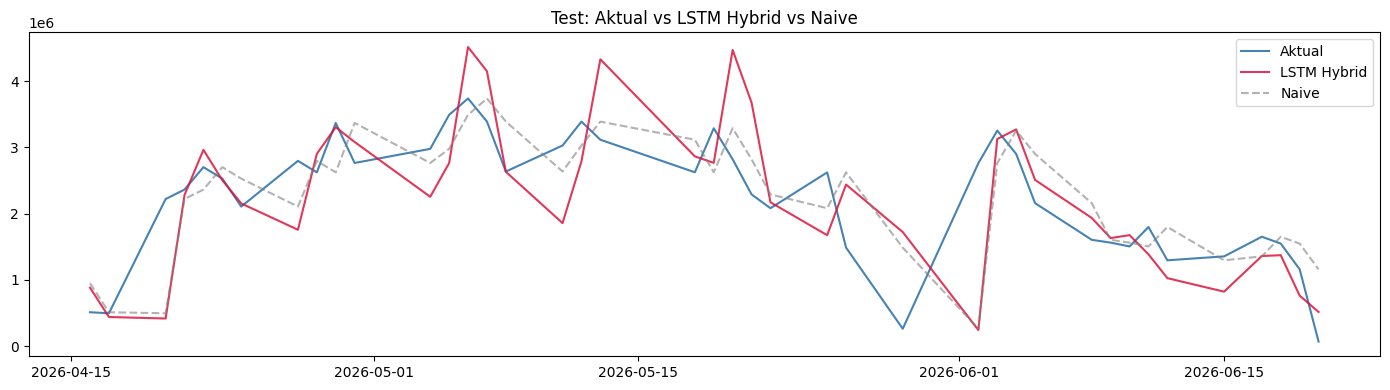

In [15]:
tbl = pd.DataFrame({
    'Model'  : ['Naive (kemarin)','Mean-7','SARIMA','LSTM Hybrid'],
    'RMSE'   : [m_naive['rmse'], m_mean7['rmse'], m_sarima['rmse'], m_lstm['rmse']],
    'MAE'    : [m_naive['mae'],  m_mean7['mae'],  m_sarima['mae'],  m_lstm['mae']],
    'sMAPE%' : [m_naive['smape'],m_mean7['smape'],m_sarima['smape'],m_lstm['smape']],
    'MASE'   : [m_naive['mase'], m_mean7['mase'], m_sarima['mase'], m_lstm['mase']],
}).sort_values('MAE').reset_index(drop=True)
print(tbl.to_string(index=False))
print('\nMASE < 1 -> kalahkan naif in-sample. Target: LSTM Hybrid MAE < Naive MAE.')

fig, ax = plt.subplots(figsize=(14,4))
d = df_te['date'].values[LOOK_BACK:]
ax.plot(d, rev_true, label='Aktual', color='steelblue')
ax.plot(d, y_lstm,  label='LSTM Hybrid', color='crimson', alpha=.85)
ax.plot(d, y_naive, label='Naive', color='gray', ls='--', alpha=.6)
ax.set_title('Test: Aktual vs LSTM Hybrid vs Naive'); ax.legend(); plt.tight_layout(); plt.show()

TEST

# Perbaikan Forecast Recursive (Hybrid) — Stabil

**Jalankan setelah Section 0–6 notebook `lstm_harian_hybrid_residual.ipynb`** (model, scaler, dfa, dll. harus sudah ada di kernel).

Masalah lama: log-return di-*compound* tiap langkah → bias negatif kecil menumpuk secara perkalian → revenue meluruh ke ~Rp 22 rb/hari.

Tiga pengaman:
1. **Clip** log-return ke persentil 10–90 data train.
2. **Damp** (φ=0.7): perubahan diredam menuju 0 seiring horizon → revert ke persistensi.
3. **Safety rail**: revenue dijepit ke rentang hari-aktif historis.

## Forecast Hybrid — versi stabil

In [16]:
# Asumsi tersedia di kernel: model, scaler, dfa, FEATURES, LOOK_BACK, inv_logret, df_tr
# ── Statistik dari data train (untuk clip & rail) ────────────────────────────
_train_logret = dfa['logret'].iloc[1:len(df_tr)].values          # logret in-sample
LR_LO, LR_HI  = np.percentile(_train_logret, [10, 90])
_act_rev      = dfa['revenue'].values
REV_FLOOR, REV_CEIL = np.percentile(_act_rev, 2), _act_rev.max()
print(f'Clip log-return : [{LR_LO:+.3f}, {LR_HI:+.3f}]')
print(f'Rail revenue    : [Rp {REV_FLOOR:,.0f}, Rp {REV_CEIL:,.0f}]')

def forecast_hybrid_stable(model, dfa, scaler, features, look_back, n_steps,
                           phi=0.7, lr_lo=LR_LO, lr_hi=LR_HI,
                           rev_floor=REV_FLOOR, rev_ceil=REV_CEIL):
    window   = scaler.transform(dfa.tail(look_back)[features].values)
    prev_rev = float(dfa['revenue'].iloc[-1])
    last_date = pd.Timestamp(dfa['date'].max())
    rows, d, step = [], last_date, 0
    while len(rows) < n_steps:
        d += pd.Timedelta(days=1)
        if d.weekday() >= 5 or d.month in [1, 7]:
            continue
        step += 1
        raw_lr  = float(inv_logret(model.predict(window[np.newaxis], verbose=0)[0, 0]))
        lr_clip = float(np.clip(raw_lr, lr_lo, lr_hi))       # 1) clip
        lr_damp = lr_clip * (phi ** (step - 1))              # 2) damp menuju 0
        rev     = float(np.expm1(np.log1p(prev_rev) + lr_damp))
        rev     = float(np.clip(rev, rev_floor, rev_ceil))   # 3) rail
        # susun baris fitur utk langkah berikutnya (logret efektif = lr_damp)
        woy = d.isocalendar().week
        raw = [lr_damp,
               np.sin(2*np.pi*woy/52), np.cos(2*np.pi*woy/52),
               np.sin(2*np.pi*d.month/12), np.cos(2*np.pi*d.month/12),
               np.sin(2*np.pi*d.weekday()/5), np.cos(2*np.pi*d.weekday()/5),
               0]
        window   = np.vstack([window[1:], scaler.transform([raw])[0]])
        prev_rev = rev
        rows.append({'tanggal': d.date(), 'hari': d.strftime('%A'),
                     'prediksi_revenue': int(round(rev))})
    return pd.DataFrame(rows)

fc = forecast_hybrid_stable(model, dfa, scaler, FEATURES, LOOK_BACK, 7)
print('\n=== Prediksi 7 Hari Aktif (Hybrid STABIL) ===')
print(fc.to_string(index=False))
print(f'\nTotal: Rp {fc.prediksi_revenue.sum():,} | Rata-rata: Rp {fc.prediksi_revenue.mean():,.0f}')

Clip log-return : [-0.455, +0.341]
Rail revenue    : [Rp 26,420, Rp 3,738,500]

=== Prediksi 7 Hari Aktif (Hybrid STABIL) ===
   tanggal      hari  prediksi_revenue
2026-06-22    Monday             45262
2026-06-23   Tuesday             49342
2026-06-24 Wednesday             57840
2026-06-25  Thursday             54492
2026-06-26    Friday             49062
2026-06-29    Monday             46948
2026-06-30   Tuesday             47105

Total: Rp 350,051 | Rata-rata: Rp 50,007


## Pembanding: Seasonal-Naive (rekomendasi untuk app)

In [17]:
# Prediksi tiap hari ke depan = rata-rata K kemunculan terakhir hari-yang-sama
def forecast_seasonal_naive(dfa, n_steps, k=4):
    last_date = pd.Timestamp(dfa['date'].max())
    by_dow = {w: dfa[dfa['day_of_week'] == w]['revenue'].tail(k).mean()
              for w in range(5)}
    rows, d = [], last_date
    while len(rows) < n_steps:
        d += pd.Timedelta(days=1)
        if d.weekday() >= 5 or d.month in [1, 7]:
            continue
        rows.append({'tanggal': d.date(), 'hari': d.strftime('%A'),
                     'prediksi_revenue': int(round(by_dow[d.weekday()]))})
    return pd.DataFrame(rows)

fc_sn = forecast_seasonal_naive(dfa, 7, k=4)
print('=== Prediksi 7 Hari Aktif (Seasonal-Naive, k=4) ===')
print(fc_sn.to_string(index=False))
print(f'\nTotal: Rp {fc_sn.prediksi_revenue.sum():,} | Rata-rata: Rp {fc_sn.prediksi_revenue.mean():,.0f}')

=== Prediksi 7 Hari Aktif (Seasonal-Naive, k=4) ===
   tanggal      hari  prediksi_revenue
2026-06-22    Monday           2051500
2026-06-23   Tuesday           2274875
2026-06-24 Wednesday           2307750
2026-06-25  Thursday           2134375
2026-06-26    Friday           1218625
2026-06-29    Monday           2051500
2026-06-30   Tuesday           2274875

Total: Rp 14,313,500 | Rata-rata: Rp 2,044,786


## Visualisasi: 30 hari historis + dua forecast

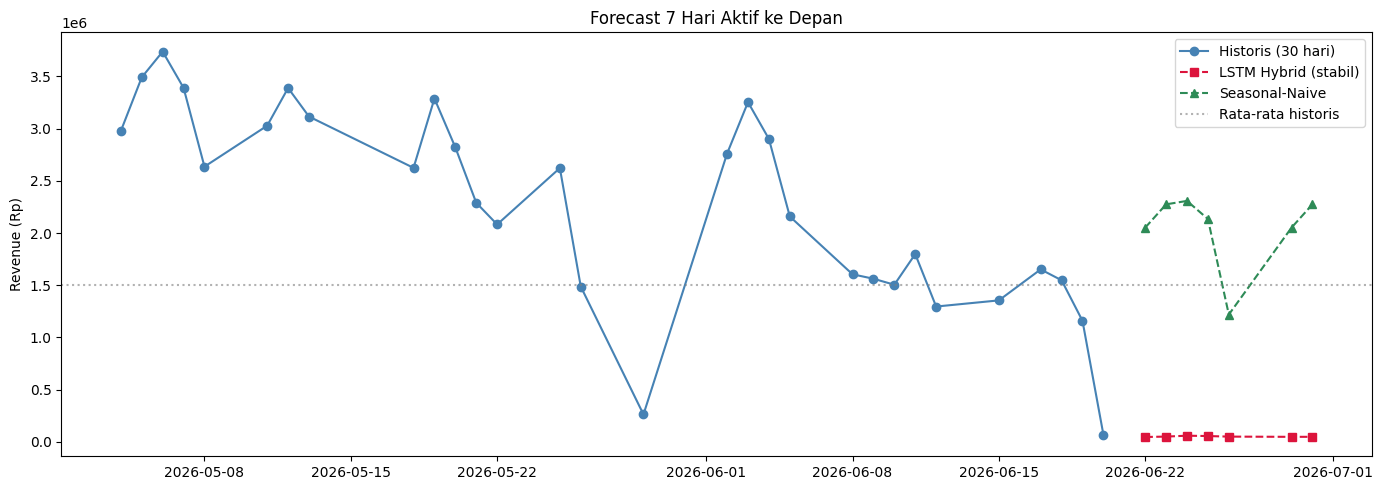

In [18]:
last30 = dfa.tail(30)[['date','revenue']].copy()
fc_d  = pd.to_datetime(fc['tanggal']);     fc_sn_d = pd.to_datetime(fc_sn['tanggal'])

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(last30['date'], last30['revenue'], 'o-', color='steelblue', label='Historis (30 hari)')
ax.plot(fc_d,   fc['prediksi_revenue'],   's--', color='crimson', label='LSTM Hybrid (stabil)')
ax.plot(fc_sn_d, fc_sn['prediksi_revenue'],'^--', color='seagreen', label='Seasonal-Naive')
ax.axhline(dfa['revenue'].mean(), color='gray', ls=':', alpha=.6, label='Rata-rata historis')
ax.set_title('Forecast 7 Hari Aktif ke Depan'); ax.legend(); ax.set_ylabel('Revenue (Rp)')
plt.tight_layout(); plt.show()

## SECTION 7 — Forecast 7 Hari Aktif ke Depan (recursive)

def forecast_hybrid(model, dfa, scaler, features, look_back, n_steps):
    window   = scaler.transform(dfa.tail(look_back)[features].values)   # (L, nfeat)
    prev_rev = float(dfa['revenue'].iloc[-1])                           # rev[t-1] awal
    last_date = pd.Timestamp(dfa['date'].max())
    rows, d = [], last_date
    while len(rows) < n_steps:
        d += pd.Timedelta(days=1)
        if d.weekday() >= 5 or d.month in [1, 7]:          # skip weekend & libur
            continue
        logret = inv_logret(model.predict(window[np.newaxis], verbose=0)[0, 0])
        rev    = float(np.expm1(np.log1p(prev_rev) + logret))           # rekonstruksi
        woy = d.isocalendar().week
        raw = [logret,
               np.sin(2*np.pi*woy/52), np.cos(2*np.pi*woy/52),
               np.sin(2*np.pi*d.month/12), np.cos(2*np.pi*d.month/12),
               np.sin(2*np.pi*d.weekday()/5), np.cos(2*np.pi*d.weekday()/5),
               0]
        window  = np.vstack([window[1:], scaler.transform([raw])[0]])
        prev_rev = rev                                                  # feedback
        rows.append({'tanggal': d.date(), 'hari': d.strftime('%A'),
                     'prediksi_revenue': int(round(rev))})
    return pd.DataFrame(rows)

fc = forecast_hybrid(model, dfa, scaler, FEATURES, LOOK_BACK, 7)
print('=== Prediksi 7 Hari Aktif ke Depan (Hybrid, recursive) ===')
print(fc.to_string(index=False))
print(f'\nTotal: Rp {fc.prediksi_revenue.sum():,} | Rata-rata: Rp {fc.prediksi_revenue.mean():,.0f}')